# AI-Powered Student Performance Prediction & Early Warning System

## Domain
Education

## Objective
To predict student academic performance using machine learning and identify students who are at risk of failing. The system also provides personalized study recommendations.

## Features
1. Student performance prediction
2. Early warning system (risk detection)
3. Personalized study recommendations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import pickle

### Load Dataset

In [2]:
df = pd.read_csv("student_performance.csv")
print(df)

     StudentID StudentName  Class  Attendance  QuizScore  AssignmentScore  \
0         1001       Aarav      9          96         92              NaN   
1         1002        Diya     10          91         88             86.0   
2         1003       Rohan      9          87         81             79.0   
3         1004       Meera     11          93         90             91.0   
4         1005       Karan     10          74         63             61.0   
..         ...         ...    ...         ...        ...              ...   
115       1116        Jiya     11          87         89             87.0   
116       1117       Nitya      9          68         72             70.0   
117       1118        Neel     11          49         31             34.0   
118       1119       Parth     10          70         71             74.0   
119       1120         Ira     11          95         95             83.0   

     InternalExam  PreviousPercentage  Participation  HomeworkCompletion  \

### Dataset Information

In [3]:
df.head()

df.tail()

df.shape

df.columns

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           120 non-null    int64  
 1   StudentName         120 non-null    object 
 2   Class               120 non-null    int64  
 3   Attendance          120 non-null    int64  
 4   QuizScore           120 non-null    int64  
 5   AssignmentScore     112 non-null    float64
 6   InternalExam        120 non-null    int64  
 7   PreviousPercentage  117 non-null    float64
 8   Participation       115 non-null    float64
 9   HomeworkCompletion  120 non-null    int64  
 10  BehaviourScore      120 non-null    int64  
 11  StudyHours          114 non-null    float64
 12  ParentMeeting       100 non-null    float64
 13  FinalPercentage     120 non-null    int64  
 14  RiskLevel           120 non-null    object 
dtypes: float64(5), int64(8), object(2)
memory usage: 14.2+ KB

,StudentID,Class,Attendance,QuizScore,AssignmentScore,InternalExam,PreviousPercentage,Participation,HomeworkCompletion,BehaviourScore,StudyHours,ParentMeeting,FinalPercentage
count,120.000000,120.000000,120.000000,120.000000,112.000000,120.000000,117.000000,115.000000,120.000000,120.000000,114.000000,100.000000,120.000000
mean,1060.500000,10.541667,74.858333,66.200000,64.705357,65.108333,67.837607,1.756522,72.600000,3.450000,2.770175,0.560000,67.258333
std,34.785054,1.060330,15.532723,20.064015,20.007944,20.457291,16.919157,0.767673,17.744877,1.172873,1.375959,0.498888,18.086392
min,1001.000000,9.000000,45.000000,30.000000,30.000000,30.000000,36.000000,1.000000,40.000000,1.000000,0.500000,0.000000,37.000000
25%,1030.750000,10.000000,62.750000,50.000000,48.750000,47.500000,55.000000,1.000000,60.000000,3.000000,1.800000,0.000000,52.000000
50%,1060.500000,11.000000,74.000000,66.500000,67.000000,65.000000,68.000000,2.000000,71.500000,4.000000,2.700000,1.000000,67.000000
75%,1090.250000,11.000000,89.000000,84.000000,82.000000,83.000000,82.000000,2.000000,89.000000,4.000000,3.475000,1.000000,84.000000
max,1120.000000,12.000000,99.000000,99.000000,99.000000,98.000000,97.000000,3.000000,100.000000,5.000000,6.000000,1.000000,97.000000


### Check Missing Values

In [5]:
print(df.isnull().sum())
#print(df.dropna())

#df.fillna(df.mean(numeric_only=True), inplace=True)
#print(df.fillna)

StudentID              0
StudentName            0
Class                  0
Attendance             0
QuizScore              0
AssignmentScore        8
InternalExam           0
PreviousPercentage     3
Participation          5
HomeworkCompletion     0
BehaviourScore         0
StudyHours             6
ParentMeeting         20
FinalPercentage        0
RiskLevel              0
dtype: int64


### Data Visualization

#### Attendance Distribution


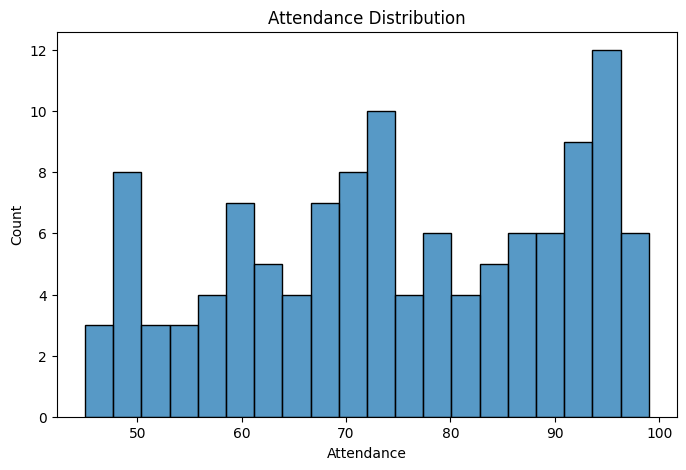

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["Attendance"], bins=20)
plt.title("Attendance Distribution")
plt.show()

#### Risk Level Count

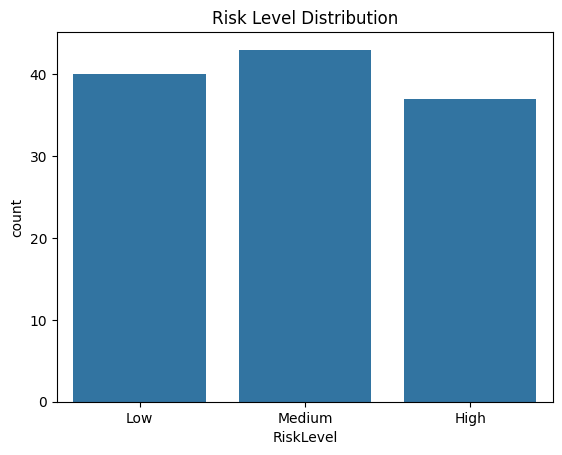

In [7]:
sns.countplot(
    x="RiskLevel",
    data=df
)

plt.title("Risk Level Distribution")
plt.show()

#### Correlation Heatmap

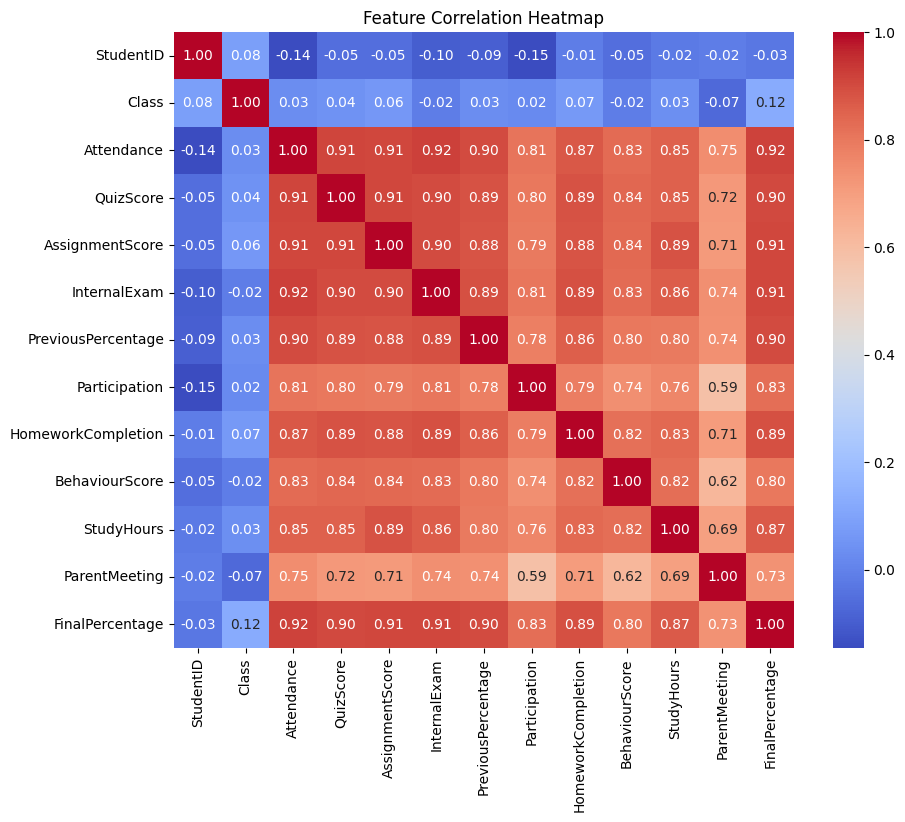

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

#### Attendance vs Final Percentage

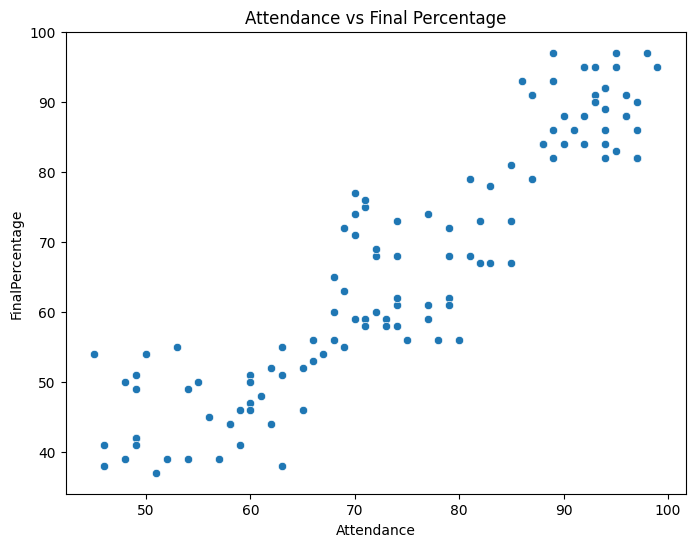

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Attendance",
    y="FinalPercentage",
    data=df
)

plt.title("Attendance vs Final Percentage")

plt.show()

#### Study Hours vs Final Percentage

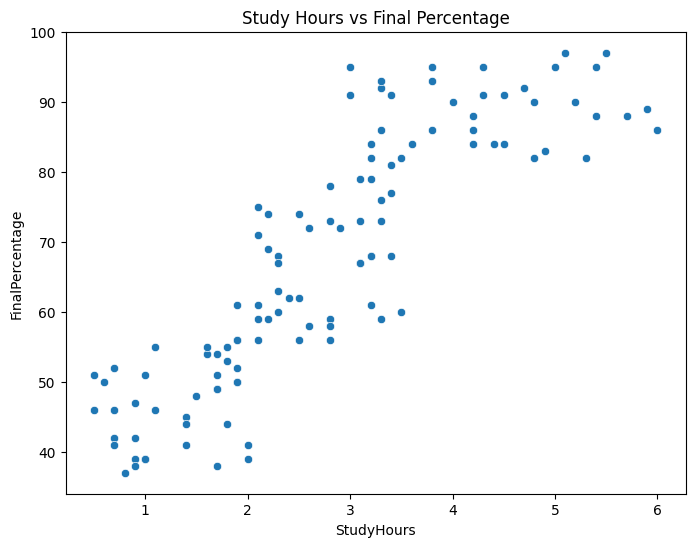

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="StudyHours",
    y="FinalPercentage",
    data=df
)

plt.title("Study Hours vs Final Percentage")

plt.show()

#### Box plot

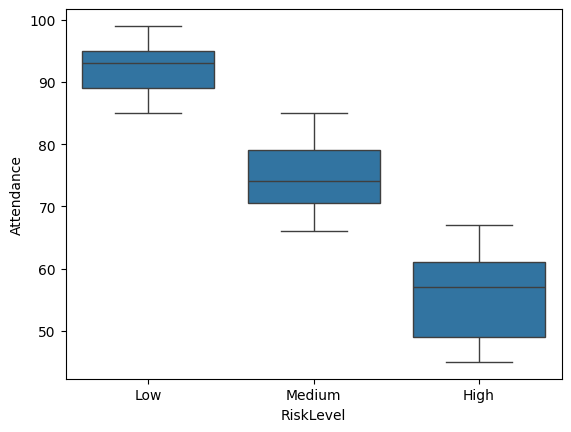

In [12]:
sns.boxplot(
    x="RiskLevel",
    y="Attendance",
    data=df
)

plt.show()

### Feature Selection

In [13]:
features = [
    "Attendance",
    "QuizScore",
    "AssignmentScore",
    "InternalExam",
    "PreviousPercentage",
    "Participation",
    "HomeworkCompletion",
    "BehaviourScore",
    "StudyHours",
    "ParentMeeting"
]

X = df[features]

y = df["RiskLevel"]

### Train/Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Train Machine Learning Model

In [15]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Model Predictions

In [16]:
predictions = model.predict(X_test)

### Model Evaluation

In [18]:
print("Accuracy")

print(
    accuracy_score(
        y_test,
        predictions
    )
)

Accuracy
1.0


#### Classification Report


In [19]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         7
         Low       1.00      1.00      1.00         8
      Medium       1.00      1.00      1.00         9

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



#### Confusion Matrix

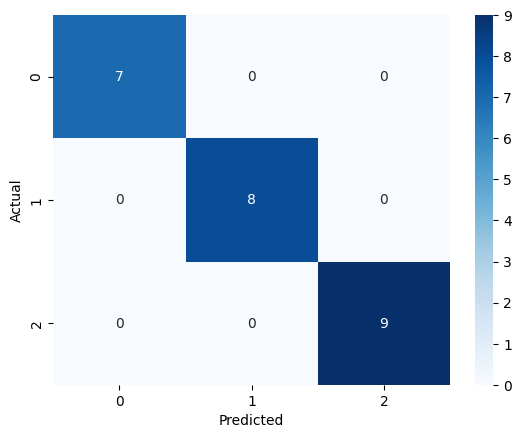

In [20]:
cm = confusion_matrix(
    y_test,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Early Warning System (Risk Classification)

In [21]:
def early_warning(risk):

    if risk == "High":
        return "Immediate Teacher Intervention Required"

    elif risk == "Medium":
        return "Monitor Weekly"

    else:
        return "Student Performing Well"

### Recommendation System

In [23]:
def recommendation(row):

    recommendations = []

    if row["Attendance"] < 75:
        recommendations.append(
            "Improve attendance"
        )

    if row["QuizScore"] < 50:
        recommendations.append(
            "Attend remedial quiz sessions"
        )

    if row["AssignmentScore"] < 50:
        recommendations.append(
            "Complete pending assignments"
        )

    if row["Participation"] < 2:
        recommendations.append(
            "Participate more in classroom activities"
        )

    if row["StudyHours"] < 2:
        recommendations.append(
            "Increase daily study time"
        )

    if len(recommendations) == 0:
        recommendations.append(
            "Keep up the excellent work"
        )

    return recommendations

### Test the System

In [24]:
new_student = pd.DataFrame({

    "Attendance":[62],
    "QuizScore":[41],
    "AssignmentScore":[55],
    "InternalExam":[48],
    "PreviousPercentage":[58],
    "Participation":[1],
    "HomeworkCompletion":[60],
    "BehaviourScore":[3],
    "StudyHours":[1.5],
    "ParentMeeting":[0]

})

#### Predict

In [25]:
prediction = model.predict(
    new_student
)

print(prediction)

['High']


#### Generate Warning

In [26]:
print(
    early_warning(
        prediction[0]
    )
)

Immediate Teacher Intervention Required


#### Generate Recommendations


In [27]:
print(
    recommendation(
        new_student.iloc[0]
    )
)

['Improve attendance', 'Attend remedial quiz sessions', 'Participate more in classroom activities', 'Increase daily study time']


### Feature Importance

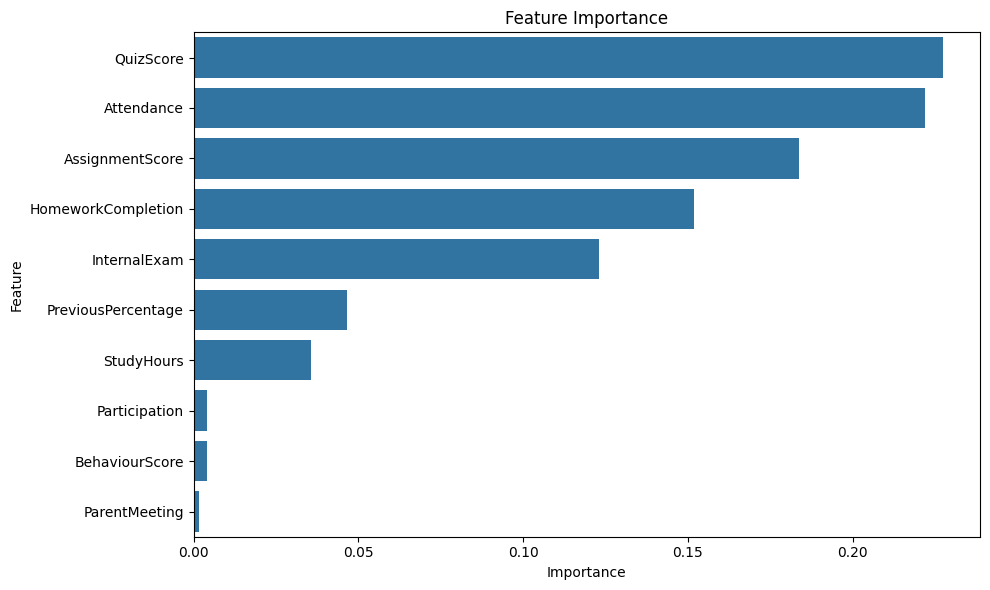

In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.tight_layout()

plt.savefig("screenshots/feature_importance.png")

plt.show()

### Save the model

In [29]:
with open(
    "student_model.pkl",
    "wb"
) as file:

    pickle.dump(
        model,
        file
    )

# Conclusion

This project demonstrates how Machine Learning can help teachers identify students who are at academic risk before final examinations. Using factors such as attendance, quiz scores, assignments, study hours, and previous performance, the system predicts a student's risk level (Low, Medium, or High) and provides personalized recommendations for early intervention.

The project shows how AI can support better decision-making in education and help improve student performance through timely guidance.

In [30]:
import os
import pickle

# Create model folder if it does not exist
os.makedirs("model", exist_ok=True)

# Save the trained classifier
with open("model/student_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("✅ Model saved successfully!")
print("📁 Location : model/student_model.pkl")

✅ Model saved successfully!
📁 Location : model/student_model.pkl
